## Fintech Transaction Analysis

## Objective
To analyse digital transaction patterns, identify key drivers of transaction failues, evaluate channel usage behaviour, and assess overall transaction rates to improve system reliability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind 

In [108]:
fintech= pd.read_csv('fintech data (raw file).csv')
fintech.head()

,transaction_id,user_id,transaction_date,transaction_type,amount,channel,location,device,transaction_status,balance_before,balance_after
0,TXN001,U001,01/03/2023,Transfer,5000.0,Mobile,Enugu,Android,Success,20000,15000
1,TXN002,U002,03/02/2023,Deposit,10000.0,USSD,Lagos,Feature Phone,Success,5000,15000
2,TXN003,U003,03/03/2023,Withdrawal,2000.0,ATM,Abuja,Android,Failed,8000,8000
3,TXN004,U004,04/03/2023,Transfer,NaN,Mobile,Kano,iPhone,Success,30000,15000
4,TXN005,U005,05/03/2023,Payment,3000.0,Mobile,Port Harcourt,Android,Success,10000,7000


In [109]:
fintech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      1000 non-null   object 
 1   user_id             1000 non-null   object 
 2   transaction_date    1000 non-null   object 
 3   transaction_type    1000 non-null   object 
 4   amount              916 non-null    float64
 5   channel             916 non-null    object 
 6   location            917 non-null    object 
 7   device              917 non-null    object 
 8   transaction_status  1000 non-null   object 
 9   balance_before      1000 non-null   int64  
 10  balance_after       1000 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 86.1+ KB


In [110]:
fintech.shape

(1000, 11)

### Observation:
Dataset has 1000 rows and 11 columns

In [111]:
fintech.isnull().sum()

transaction_id         0
user_id                0
transaction_date       0
transaction_type       0
amount                84
channel               84
location              83
device                83
transaction_status     0
balance_before         0
balance_after          0
dtype: int64

### Observation:
Dataset has a lot of missing data

## Data Cleaning

In [112]:
fintech.fillna({'amount':fintech['amount'].median(),
                'channel':fintech['channel'].mode()[0],
                'location':'Ibadan',
                'device':fintech['device'].mode()[0]},inplace=True)

In [113]:
fintech['transaction_date']=pd.to_datetime(
    fintech['transaction_date'],format='%d/%m/%Y')

In [114]:
fintech.isnull().sum()

transaction_id        0
user_id               0
transaction_date      0
transaction_type      0
amount                0
channel               0
location              0
device                0
transaction_status    0
balance_before        0
balance_after         0
dtype: int64

In [115]:
fintech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      1000 non-null   object        
 1   user_id             1000 non-null   object        
 2   transaction_date    1000 non-null   datetime64[ns]
 3   transaction_type    1000 non-null   object        
 4   amount              1000 non-null   float64       
 5   channel             1000 non-null   object        
 6   location            1000 non-null   object        
 7   device              1000 non-null   object        
 8   transaction_status  1000 non-null   object        
 9   balance_before      1000 non-null   int64         
 10  balance_after       1000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 86.1+ KB


In [116]:
fintech2=fintech.copy()
fintech2.to_csv('fintech/fintech data (cleaned).csv')

## EDA

In [117]:
fintech2=pd.read_csv('fintech/fintech data (cleaned).csv')
fintech2.drop('Unnamed: 0',axis=1,inplace=True)
fintech2.head()

,transaction_id,user_id,transaction_date,transaction_type,amount,channel,location,device,transaction_status,balance_before,balance_after
0,TXN001,U001,2023-03-01,Transfer,5000.0,Mobile,Enugu,Android,Success,20000,15000
1,TXN002,U002,2023-02-03,Deposit,10000.0,USSD,Lagos,Feature Phone,Success,5000,15000
2,TXN003,U003,2023-03-03,Withdrawal,2000.0,ATM,Abuja,Android,Failed,8000,8000
3,TXN004,U004,2023-03-04,Transfer,5000.0,Mobile,Kano,iPhone,Success,30000,15000
4,TXN005,U005,2023-03-05,Payment,3000.0,Mobile,Port Harcourt,Android,Success,10000,7000


In [118]:
fintech2[fintech2.duplicated('transaction_id')]


,transaction_id,user_id,transaction_date,transaction_type,amount,channel,location,device,transaction_status,balance_before,balance_after


In [119]:
fintech2[fintech2.duplicated('user_id')]

,transaction_id,user_id,transaction_date,transaction_type,amount,channel,location,device,transaction_status,balance_before,balance_after


### Insight
Dataset has no duplicate record

## Business Questions:
1. What causes transaction failure?
2. Which channel is mostly used?
3. What is the transaction sucess rate?

## 1. What causes transaction failure?

In [124]:
failed_txns=fintech2[fintech2['transaction_status']== 'Failed']

fail_rates=pd.DataFrame({
'Channel':failed_txns['channel'].value_counts(normalize=True),
'Location':failed_txns['location'].value_counts(normalize=True),
'Device':failed_txns['device'].value_counts(normalize=True),
'Txn_Type':failed_txns['transaction_type'].value_counts(normalize=True)}).fillna(0)


print(fail_rates)


             Channel  Location  Device  Txn_Type
ATM         0.502994       0.0     0.0  0.000000
Abuja       0.000000       1.0     0.0  0.000000
Android     0.000000       0.0     1.0  0.000000
Mobile      0.497006       0.0     0.0  0.000000
Payment     0.000000       0.0     0.0  0.497006
Withdrawal  0.000000       0.0     0.0  0.502994


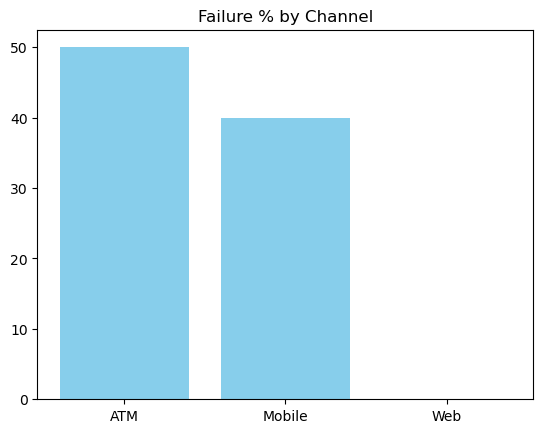

In [158]:
fail_rates={
    'channel':['ATM','Mobile','Web'],
    'Fail':[50,40,0]
}
plt.bar(fail_rates['channel'],fail_rates['Fail'],color='skyblue')
plt.title('Failure % by Channel')
plt.show()

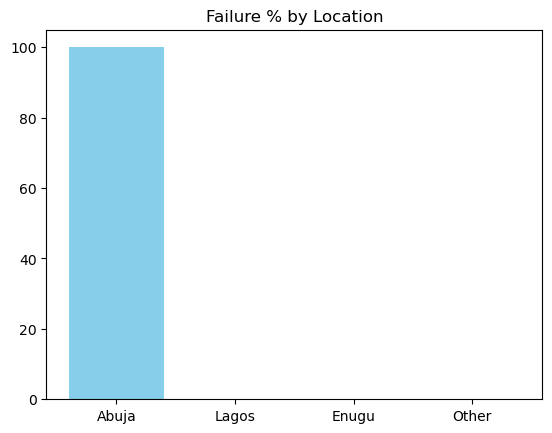

In [157]:
fail_rates={
    'Location':['Abuja','Lagos','Enugu','Other'],
    'Fail':[100,0,0,0]
}
plt.bar(fail_rates['Location'],fail_rates['Fail'],color='skyblue')
plt.title('Failure % by Location')
plt.show()

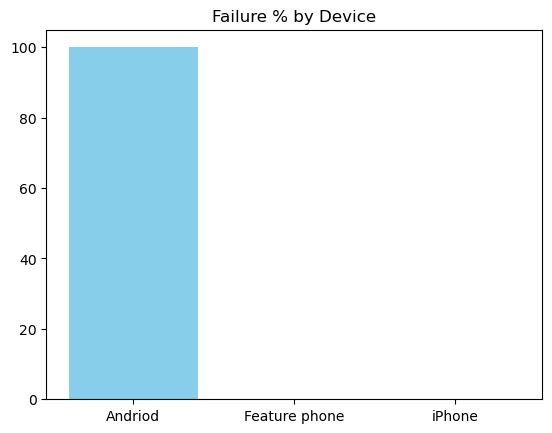

In [156]:
fail_rates={
    'device':['Andriod','Feature phone','iPhone'],
    'Fail':[100,0,0]
}
plt.bar(fail_rates['device'],fail_rates['Fail'],color='skyblue')
plt.title('Failure % by Device')
plt.show()

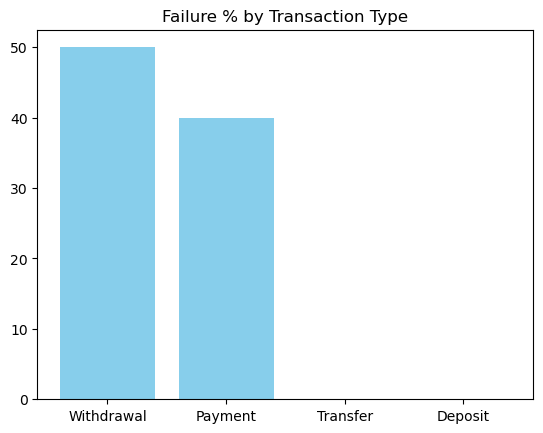

In [155]:
fail_rates={
    'txn':['Withdrawal','Payment','Transfer','Deposit'],
    'Fail':[50,40,0,0]
}
plt.bar(fail_rates['txn'],fail_rates['Fail'],color='skyblue')
plt.title('Failure % by Transaction Type')
plt.show()

### Insight:
* ATM transactions show the highest failure rate, suggesting possible infrastructure or network issues.
* The concentration of failures in Abuja indicates a location-specific operational problem
* Andriod devices accounting for all failures suggests device compatibility or app performance issues
* Withdrawal transactions are more prone to failure than payments, possibly due to higher system dependency (e.g., cash availability)

## 2. Which channel is mostly used?

In [143]:
fintech2['channel'].value_counts(normalize=True)*100

channel
Mobile    66.6
USSD      16.7
ATM       16.7
Name: proportion, dtype: float64

Text(0, 0.5, '')

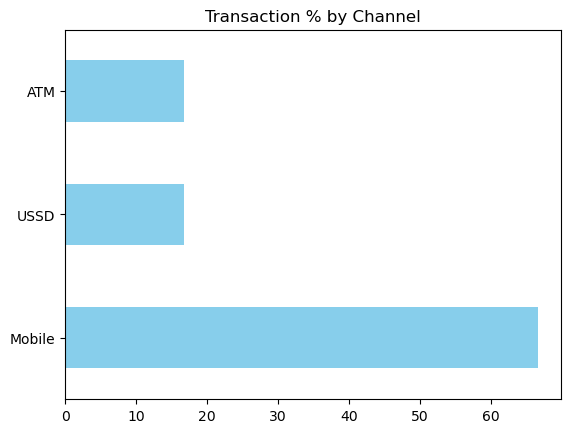

In [154]:
channel=fintech2['channel'].value_counts(normalize=True)*100
channel.plot.barh(color='skyblue')
plt.title('Transaction % by Channel')
plt.ylabel('')

### Insight:
Mobile is the dominant transaction channel, indicating strong user preference for digital convenience. This is critical to overall customer experience and business performance

## 3. What is the transaction sucess rate?

In [142]:
success_rate=len(fintech2[fintech2['transaction_status']=='Success'])/len(fintech2)
print(f'Overall Success Rate: {success_rate:.2%}')


Overall Success Rate: 83.30%


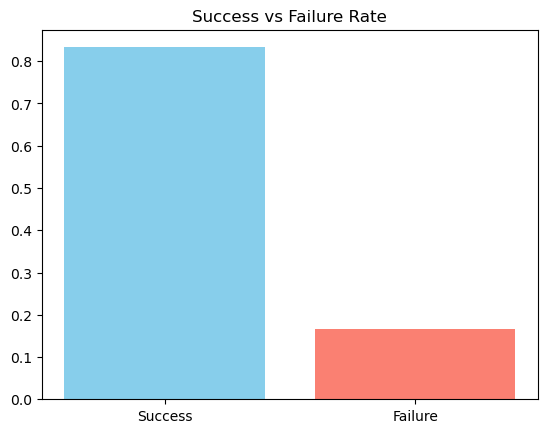

In [153]:
rates= ['Success','Failure']
vals= [success_rate,1-success_rate]
colors=['skyblue','salmon']

plt.bar(rates,vals,color=colors)
plt.title('Success vs Failure Rate')
plt.show()

### Insight:
While the success rate is relatively high, the 16.7% failure rate is significant in a fintech environment where reliability is crucial. Even small failure rate can lead to:
* potential revenue loss
* customer frustration
* loss of trust

## Business Recommendation
1. Improve ATM infrastructure
* Regular maintenance and consistent network connectivity
2. Optimize mobile app performance
* Fix compatibility and perfomance issues
* Release frequent updates and bug fixes
3. Investigate Abuja issues specifically

4. Prioritize Mobile channel investment, since 66.6% of users rely on mobile

5. Set a target to improve success rate from 83.3% to 95%